Pipline()

Data Manager (Download, organize with_mask/without_mask folders, verify quality)

In [ ]:
!pip install torch torchvision fastapi uvicorn python-multipart Pillow scikit-learn

In [ ]:
import kagglehub
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import random
import torch
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 330M/330M [00:22<00:00, 15.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1
Files: ['Face Mask Dataset']


In [ ]:
train_data = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Train"))
val_data   = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Validation"))
test_data  = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Test"))

In [ ]:
print(len(train_data))
print(train_data.classes)

10000
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(train_data.targets)
classes = train_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 5000 images
WithoutMask: 5000 images


In [ ]:
print(len(val_data))
print(val_data.classes)

800
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(val_data.targets)
classes = val_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 400 images
WithoutMask: 400 images


In [ ]:
print(len(test_data))
print(test_data.classes)

992
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(test_data.targets)
classes = test_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 483 images
WithoutMask: 509 images


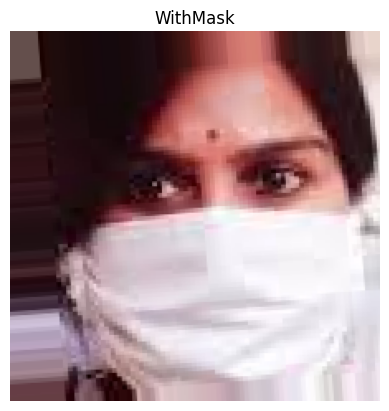

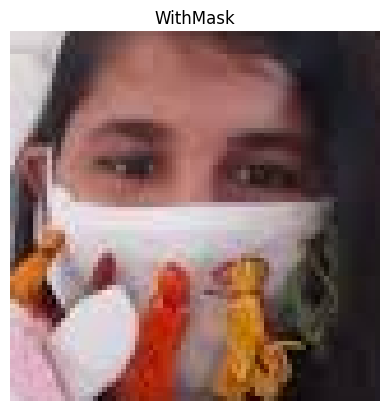

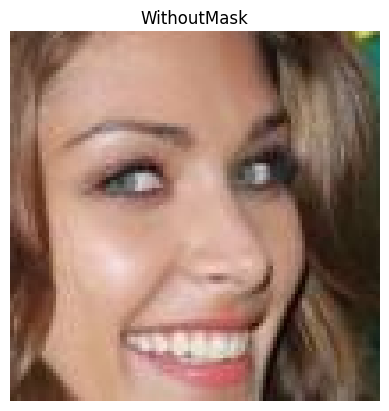

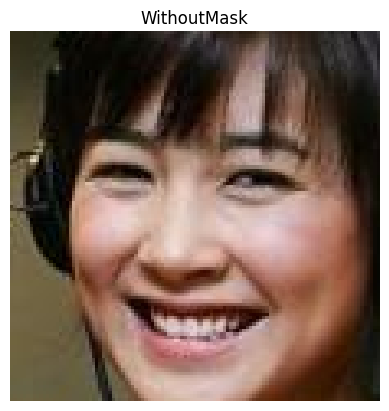

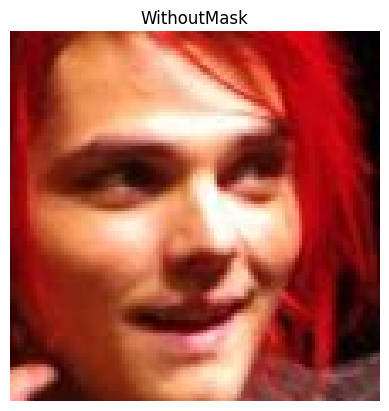

In [ ]:
for i in range(5):
    img, label = train_data[random.randint(0, len(train_data)-1)]
    plt.imshow(img)
    plt.title(train_data.classes[label])
    plt.axis("off")
    plt.show()

EDA & Visualizer (Sample images per class, face diversity analysis, statistics)

In [ ]:
def sampleImagesPerClass(dataset, class_name, n=2):
    class_idx = dataset.class_to_idx[class_name]
    samples = [s for s in dataset.samples if s[1] == class_idx]

    for i in range(n):
        img_path, _ = random.choice(samples)
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.show()

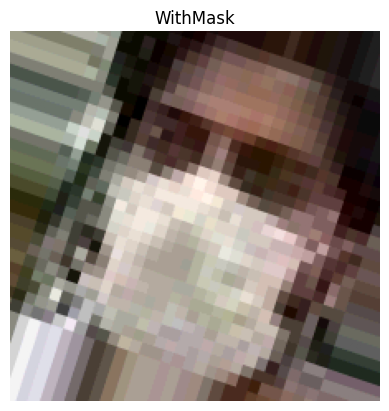

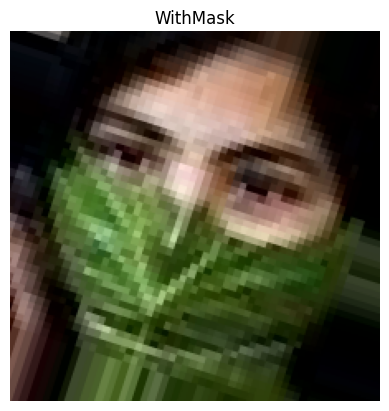

In [ ]:
sampleImagesPerClass(train_data, "WithMask")

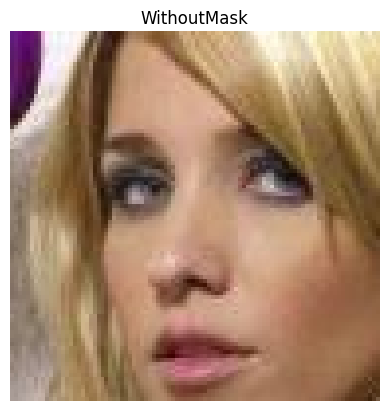

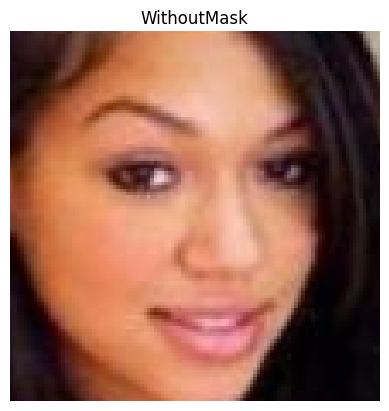

In [ ]:
sampleImagesPerClass(train_data, "WithoutMask")

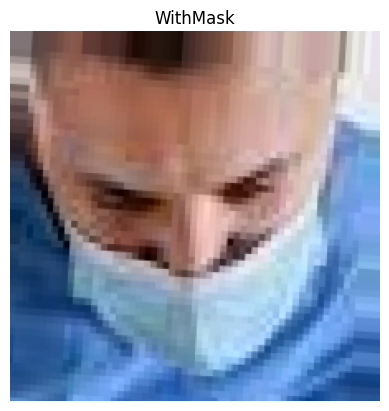

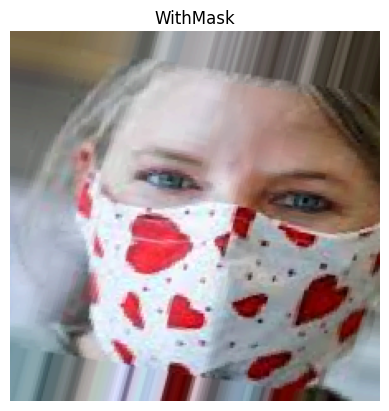

In [ ]:
sampleImagesPerClass(val_data, "WithMask")

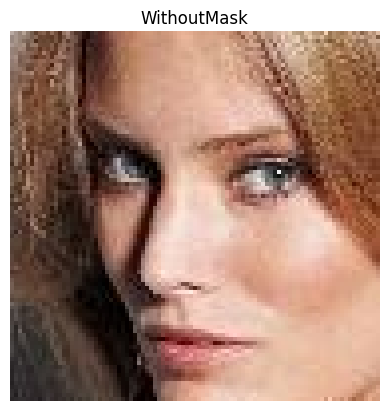

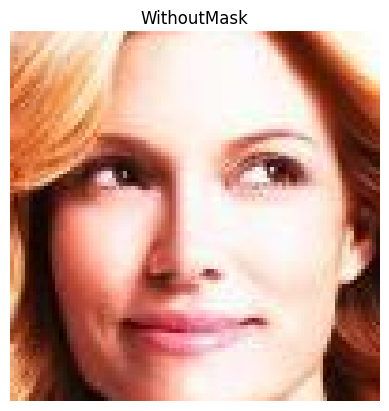

In [ ]:
sampleImagesPerClass(val_data, "WithoutMask")

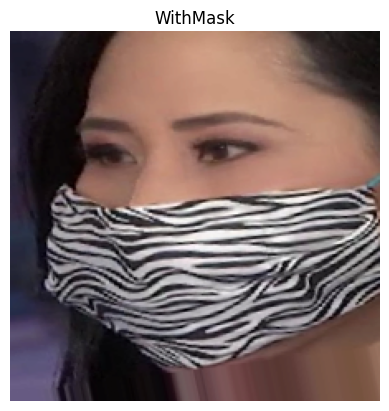

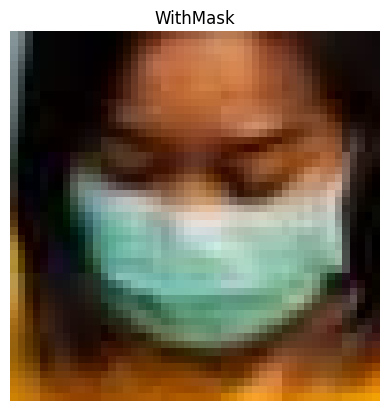

In [ ]:
sampleImagesPerClass(test_data, "WithMask")

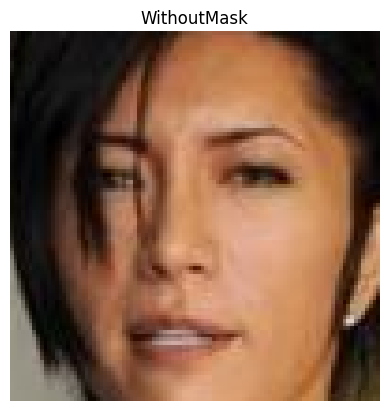

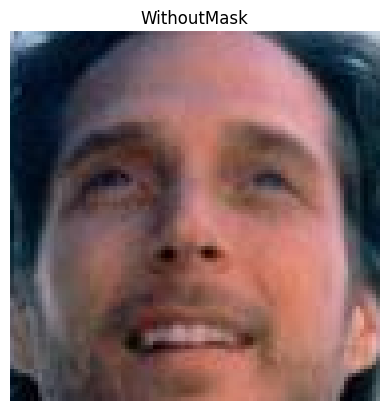

In [ ]:
sampleImagesPerClass(test_data, "WithoutMask")

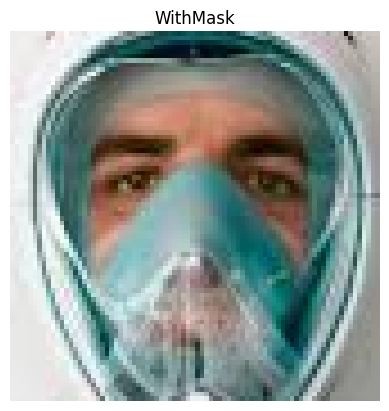

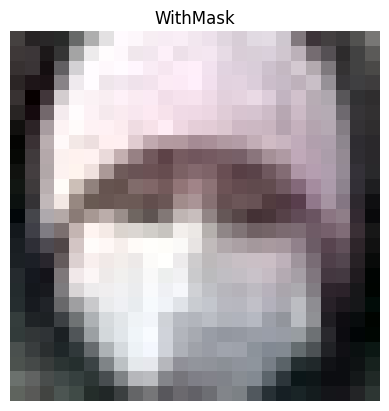

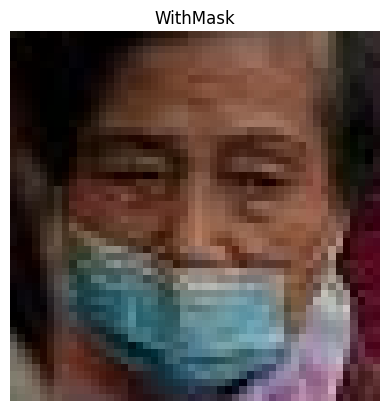

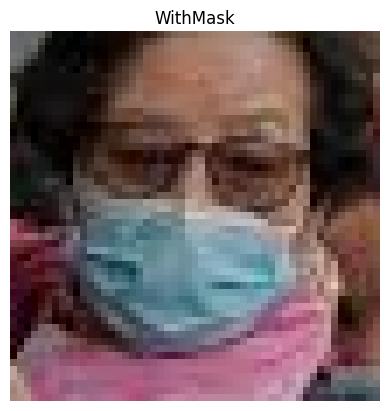

In [ ]:
for i in range(4):
    img, label = train_data[i]
    plt.imshow(img)
    plt.title(train_data.classes[label])
    plt.axis("off")
    plt.show()

#Analysis


A highly pixelated masked face (low resolution)




**Variation in mask types**: Includes respirators, surgical masks, and combinations with eyeglasses.



**Different image qualities**: One image is pixelated, which is useful for testing robustness under poor resolution.

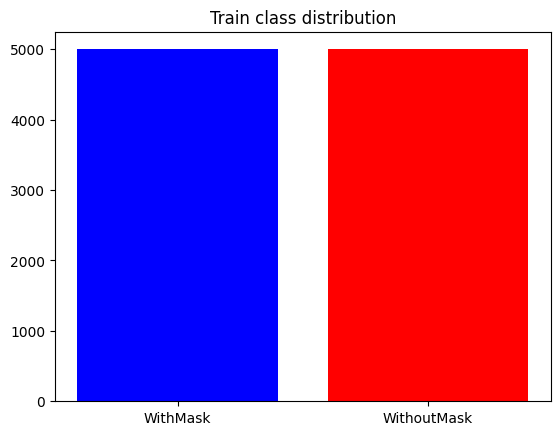

In [ ]:
class_counts = Counter(train_data.targets)
classes = train_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Train class distribution")
plt.show()

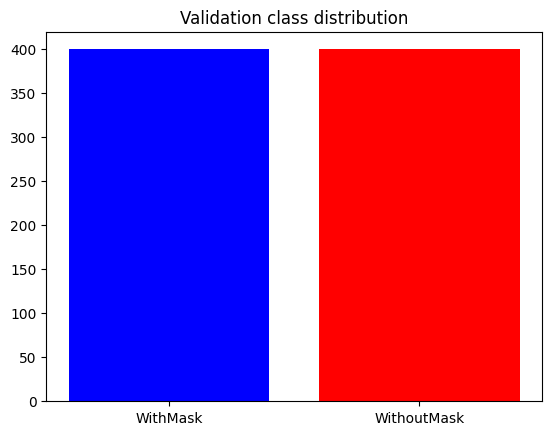

In [ ]:
class_counts = Counter(val_data.targets)
classes = val_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Validation class distribution")
plt.show()

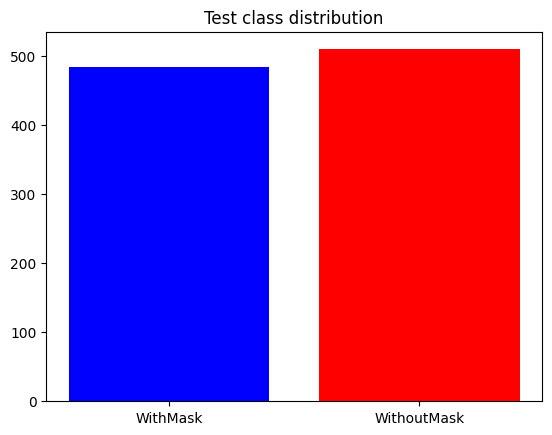

In [ ]:
class_counts = Counter(test_data.targets)
classes = test_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Test class distribution")
plt.show()

Image Size Distribution

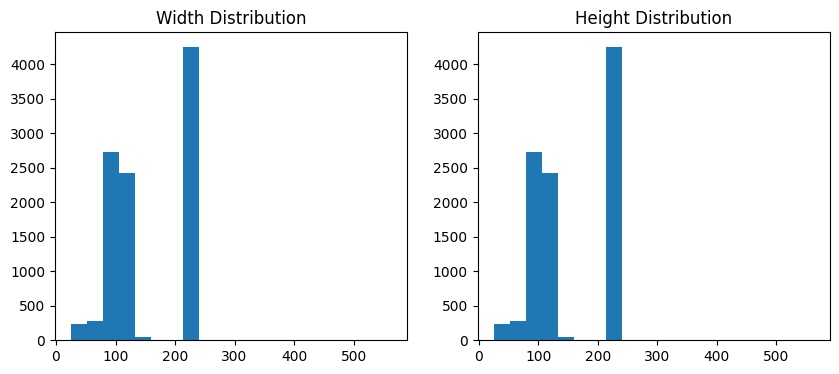

In [ ]:
sizes = [Image.open(img_path).size for img_path, _ in train_data.samples]
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Height Distribution")

plt.show()

Brightness Distribution

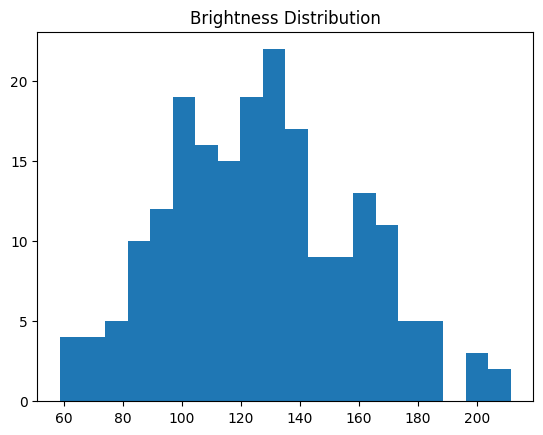

In [ ]:
import numpy as np

def get_brightness(img_path):
    img = Image.open(img_path).convert("L")
    return np.array(img).mean()

brightness = [get_brightness(img_path) for img_path, _ in random.sample(train_data.samples, 200)]

plt.hist(brightness, bins=20)
plt.title("Brightness Distribution")
plt.show()